# 03 — KNN Collaborative Filtering - — Sistema de Recomendação de Cursos - DEV
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Este notebook validaa o pipeline ponta a ponta com a implementação inicial de KNN item-based e user-based. Resultados preliminares para apresentação.
>
> **Base**: `surprise_train.parquet` / `surprise_test.parquet` (Ramo A — dedup/qtl + USS/ISS)

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNWithMeans, SVD, accuracy
from surprise.model_selection import cross_validate
from collections import defaultdict
import time

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Imports OK')

Imports OK


---
## 1. Carregamento dos dados

In [2]:
# Carrega triplas (user, item, rating) geradas pelo pipeline
train_raw = pd.read_parquet('../data/surprise_train.parquet')
test_raw  = pd.read_parquet('../data/surprise_test.parquet')

print(f'Treino: {len(train_raw):,} triplas | {train_raw["reviewers"].nunique():,} users | {train_raw["course_id"].nunique()} cursos')
print(f'Teste:  {len(test_raw):,} triplas | {test_raw["reviewers"].nunique():,} users | {test_raw["course_id"].nunique()} cursos')
print(f'Rating scale: {train_raw["rating"].min()} – {train_raw["rating"].max()}')


Treino: 121,009 triplas | 49,066 users | 223 cursos
Teste:  115,442 triplas | 50,552 users | 228 cursos
Rating scale: 1 – 5


In [3]:
# Converte para formato Surprise
reader = Reader(rating_scale=(1, 5))

train_surprise = Dataset.load_from_df(
    train_raw[['reviewers', 'course_id', 'rating']], reader
).build_full_trainset()

# Testset no formato Surprise: lista de (user, item, rating)
# Filtra apenas usuários e cursos presentes no treino (avaliação pura de CF)
train_users = set(train_raw['reviewers'].unique())
train_items = set(train_raw['course_id'].unique())
test_known = test_raw[
    test_raw['reviewers'].isin(train_users) & 
    test_raw['course_id'].isin(train_items)
]

testset = list(test_known[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))

print(f'Trainset: {train_surprise.n_users} users, {train_surprise.n_items} items, {train_surprise.n_ratings:,} ratings')
print(f'Testset (known only): {len(testset):,} triplas')
print(f'Testset descartado (cold start): {len(test_raw) - len(test_known):,} triplas')

Trainset: 49066 users, 223 items, 121,009 ratings
Testset (known only): 55,472 triplas
Testset descartado (cold start): 59,970 triplas


---
## 2. KNN Item-Based (cosseno ajustado)

Referência: Suryani et al. (2024) — K ótimo entre 120–160, cosseno ajustado + weighted sum ajustado.

In [4]:
# Modelo mais simples: KNNWithMeans item-based, cosseno (MSD como fallback rápido)
# KNNWithMeans já faz o mean-centering internamente

sim_options_item = {
    'name': 'cosine',
    'user_based': False  # item-based
}

knn_item = KNNWithMeans(k=40, sim_options=sim_options_item, verbose=False)

t0 = time.time()
knn_item.fit(train_surprise)
t_fit = time.time() - t0
print(f'KNN Item-Based treinado em {t_fit:.1f}s')

t0 = time.time()
preds_item = knn_item.test(testset)
t_pred = time.time() - t0
print(f'Predição em {t_pred:.1f}s ({len(preds_item):,} ratings)')

rmse_item = accuracy.rmse(preds_item, verbose=False)
mae_item  = accuracy.mae(preds_item, verbose=False)
print(f'\nRMSE: {rmse_item:.4f}')
print(f'MAE:  {mae_item:.4f}')
print(f'\n(Ref. Suryani K=150: RMSE=0.7882, MAE=0.4791)')

KNN Item-Based treinado em 0.0s
Predição em 0.2s (55,472 ratings)

RMSE: 0.8369
MAE:  0.5058

(Ref. Suryani K=150: RMSE=0.7882, MAE=0.4791)


---
## 3. KNN User-Based

Referência: Jena et al. (2023) — KNN user-based com cosseno.

In [5]:
sim_options_user = {
    'name': 'cosine',
    'user_based': True,
    'min_support': 5  # exige pelo menos 5 itens em comum para calcular similaridade
}

knn_user = KNNWithMeans(k=40, sim_options=sim_options_user, verbose=False)

t0 = time.time()
knn_user.fit(train_surprise)
t_fit = time.time() - t0
print(f'KNN User-Based treinado em {t_fit:.1f}s')
print(f'(min_support=5 para viabilizar matriz de similaridade {train_surprise.n_users}×{train_surprise.n_users})')

t0 = time.time()
preds_user = knn_user.test(testset)
t_pred = time.time() - t0
print(f'Predição em {t_pred:.1f}s ({len(preds_user):,} ratings)')

rmse_user = accuracy.rmse(preds_user, verbose=False)
mae_user  = accuracy.mae(preds_user, verbose=False)
print(f'\nRMSE: {rmse_user:.4f}')
print(f'MAE:  {mae_user:.4f}')

KNN User-Based treinado em 54.9s
(min_support=5 para viabilizar matriz de similaridade 49066×49066)
Predição em 8.7s (55,472 ratings)

RMSE: 0.8907
MAE:  0.5199


---
## 4. SVD (baseline rápido para comparação)

In [6]:
svd = SVD(n_factors=50, n_epochs=20, random_state=42, verbose=False)

t0 = time.time()
svd.fit(train_surprise)
t_fit = time.time() - t0
print(f'SVD treinado em {t_fit:.1f}s')

t0 = time.time()
preds_svd = svd.test(testset)
t_pred = time.time() - t0
print(f'Predição em {t_pred:.1f}s')

rmse_svd = accuracy.rmse(preds_svd, verbose=False)
mae_svd  = accuracy.mae(preds_svd, verbose=False)
print(f'\nRMSE: {rmse_svd:.4f}')
print(f'MAE:  {mae_svd:.4f}')

SVD treinado em 0.2s
Predição em 0.1s

RMSE: 0.7158
MAE:  0.4596


---
## 5. Precision@K

In [7]:
def precision_at_k(predictions, k=10, threshold=4.0):
    """Precision@K: proporção de itens relevantes (rating >= threshold) no top-K."""
    # Agrupa predições por usuário
    user_est = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est[uid].append((est, true_r))
    
    precisions = []
    for uid, ratings in user_est.items():
        # Ordena por rating estimado (maior primeiro)
        ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = ratings[:k]
        # Conta quantos dos top-K são realmente relevantes
        n_relevant = sum(1 for (est, true_r) in top_k if true_r >= threshold)
        precisions.append(n_relevant / k)
    
    return np.mean(precisions)

# Calcula para K = 5 e 10
for k_val in [5, 10]:
    p_item = precision_at_k(preds_item, k=k_val)
    p_user = precision_at_k(preds_user, k=k_val)
    p_svd  = precision_at_k(preds_svd, k=k_val)
    print(f'Precision@{k_val}:  Item={p_item:.4f}  User={p_user:.4f}  SVD={p_svd:.4f}')

Precision@5:  Item=0.3857  User=0.3840  SVD=0.3856
Precision@10:  Item=0.2129  User=0.2127  SVD=0.2129


---
## 6. Comparação dos modelos

In [8]:
# Tabela comparativa
results = pd.DataFrame({
    'Modelo': ['KNN Item-Based', 'KNN User-Based', 'SVD (50 fatores)', 'Ref. Suryani (K=150)'],
    'RMSE':   [rmse_item, rmse_user, rmse_svd, 0.7882],
    'MAE':    [mae_item, mae_user, mae_svd, 0.4791],
    'P@5':    [
        precision_at_k(preds_item, k=5),
        precision_at_k(preds_user, k=5),
        precision_at_k(preds_svd, k=5),
        np.nan
    ],
    'P@10':   [
        precision_at_k(preds_item, k=10),
        precision_at_k(preds_user, k=10),
        precision_at_k(preds_svd, k=10),
        np.nan
    ]
})

display(results.round(4))

,Modelo,RMSE,MAE,P@5,P@10
0,KNN Item-Based,0.8369,0.5058,0.3857,0.2129
1,KNN User-Based,0.8907,0.5199,0.3840,0.2127
2,SVD (50 fatores),0.7158,0.4596,0.3856,0.2129
3,Ref. Suryani (K=150),0.7882,0.4791,NaN,NaN


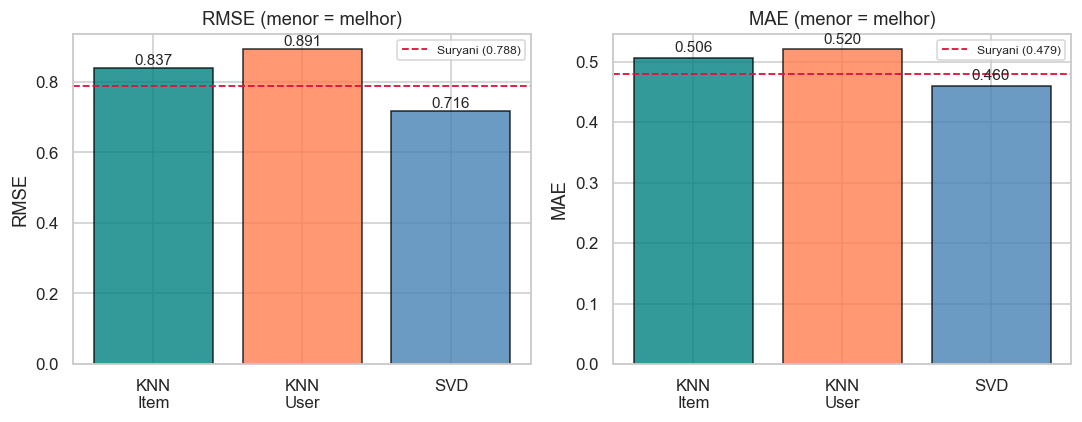

In [17]:
# Gráfico comparativo RMSE / MAE (com referência Suryani)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = ['KNN\nItem', 'KNN\nUser', 'SVD']
colors = ['teal', 'coral', 'steelblue']

# RMSE
rmse_vals = [rmse_item, rmse_user, rmse_svd]
bars = axes[0].bar(models, rmse_vals, color=colors, edgecolor='black', alpha=0.8)
axes[0].axhline(0.7882, color='crimson', linestyle='--', linewidth=1.2, label='Suryani (0.788)')
axes[0].set_title('RMSE (menor = melhor)')
axes[0].set_ylabel('RMSE')
axes[0].legend(fontsize=8)

for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
                ha='center', fontsize=10)

# MAE
mae_vals = [mae_item, mae_user, mae_svd]
bars = axes[1].bar(models, mae_vals, color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0.4791, color='crimson', linestyle='--', linewidth=1.2, label='Suryani (0.479)')
axes[1].set_title('MAE (menor = melhor)')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=8)

for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Exemplo de recomendação

In [10]:
# Pega um usuário do teste que também está no treino
sample_user = test_known['reviewers'].value_counts().index[3847]

# Cursos que o usuário já avaliou no treino
already_rated = set(train_raw[train_raw['reviewers'] == sample_user]['course_id'])

# Cursos do catálogo que o usuário NÃO avaliou
all_courses = set(train_raw['course_id'].unique())
to_predict = all_courses - already_rated

# Prediz rating para cada curso não avaliado
predictions = []
for course in to_predict:
    pred = knn_item.predict(sample_user, course)
    predictions.append((course, pred.est))

# Top 10 recomendações
predictions.sort(key=lambda x: x[1], reverse=True)
top10 = predictions[:10]

# Carrega nomes dos cursos
courses_df = pd.read_parquet('../data/courses.parquet')
course_names = dict(zip(courses_df['course_id'], courses_df['name']))

print(f'Usuário: {sample_user}')
print(f'Cursos já avaliados: {len(already_rated)}')
print(f'\nTop 10 recomendações (KNN Item-Based):')
for i, (cid, est) in enumerate(top10, 1):
    name = course_names.get(cid, cid)
    print(f'  {i:2d}. [{est:.2f}] {name}')


Usuário: LINDA A L
Cursos já avaliados: 8

Top 10 recomendações (KNN Item-Based):
   1. [5.00] Supply Chain Logistics
   2. [5.00] English for Journalism
   3. [5.00] The Science of Well-Being
   4. [5.00] Learning How to Learn: Powerful mental tools to help you master tough subjects
   5. [5.00] Introduction to CSS3
   6. [5.00] Aprendiendo a aprender: Poderosas herramientas mentales con las que podrás dominar temas difíciles (Learning How to Learn)
   7. [5.00] Introduction to TensorFlow for Artificial Intelligence, Machine Learning, and Deep Learning
   8. [5.00] Introduction to Engineering Mechanics
   9. [5.00] Basic Statistics
  10. [5.00] Introduction to Psychology


---
## 8. Análise de erros (rápida)

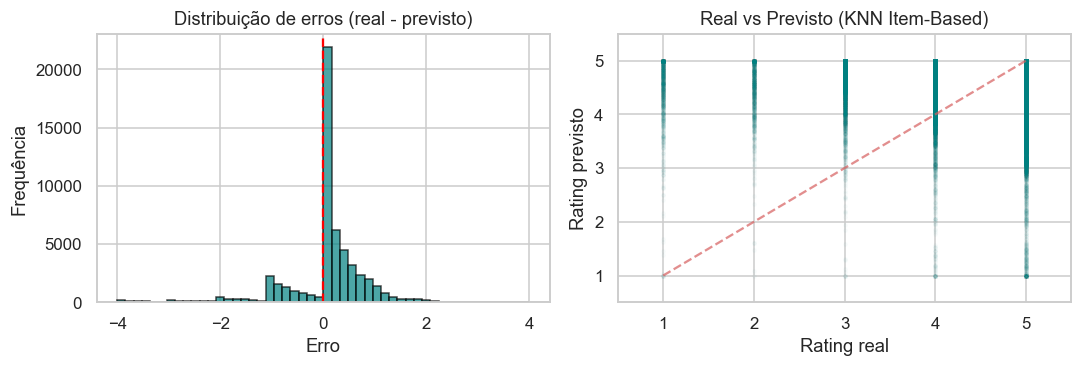


Viés médio por rating real (KNN Item-Based):
  1★: viés=+3.376, n=763
  2★: viés=+2.389, n=763
  3★: viés=+1.441, n=1,971
  4★: viés=+0.550, n=8,715
  5★: viés=-0.342, n=43,260


In [11]:
# Distribuição dos erros (real - previsto) para KNN Item-Based
errors_item = [(p.r_ui - p.est) for p in preds_item]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Histograma de erros
axes[0].hist(errors_item, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribuição de erros (real - previsto)')
axes[0].set_xlabel('Erro')
axes[0].set_ylabel('Frequência')

# Real vs Previsto
actuals = [p.r_ui for p in preds_item]
estimated = [p.est for p in preds_item]
axes[1].scatter(actuals, estimated, alpha=0.02, s=5, color='teal')
axes[1].plot([1, 5], [1, 5], 'r--', alpha=0.7)
axes[1].set_xlabel('Rating real')
axes[1].set_ylabel('Rating previsto')
axes[1].set_title('Real vs Previsto (KNN Item-Based)')
axes[1].set_xlim(0.5, 5.5)
axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.show()

# Viés por rating
error_by_rating = defaultdict(list)
for p in preds_item:
    error_by_rating[int(p.r_ui)].append(p.est - p.r_ui)

print('\nViés médio por rating real (KNN Item-Based):')
for r in sorted(error_by_rating):
    errs = error_by_rating[r]
    print(f'  {r}★: viés={np.mean(errs):+.3f}, n={len(errs):,}')

---
## Notas para versão final

Este notebook é um **proof of concept**. Para a versão final:
- Sweep de K (20–180) com curva MAE/RMSE × K
- Testar `pearson_baseline` além de cosseno
- Mover lógica reutilizável para `src/`
- Avaliar cold start separadamente (usuários órfãos)
- Comparar com cosseno ajustado (Suryani)

---
## 9. Teste de ablação — efeito do corte de percentil

O pipeline aplica um corte no percentil 99,9 de atividade por usuário **antes** dos filtros USS/ISS. Esse corte remove super-usuários (contas com centenas de avaliações) que podem ser agregadas, bots ou perfis anômalos. Para quantificar o efeito dessa etapa, treinamos o SVD com os mesmos parâmetros sobre a base **sem** o corte de percentil (apenas dedup + USS/ISS).

In [24]:
# --- Prepara base SEM corte de percentil ---
reviews_no_qtl = pd.read_parquet('../data/reviews_DEDUP.parquet')
courses_df_abl = pd.read_parquet('../data/courses.parquet')
reviews_no_qtl = reviews_no_qtl[reviews_no_qtl['course_id'].isin(courses_df_abl['course_id'])]

# USS/ISS com limiar 0.96 (mesmo do pipeline original)
user_counts = reviews_no_qtl.groupby('reviewers', observed=False).size()
uss = 1 - (user_counts / user_counts.max())
valid_users = uss[uss <= 0.96].index

item_counts = reviews_no_qtl.groupby('course_id', observed=False).size()
iss = 1 - (item_counts / item_counts.max())
valid_items = iss[iss <= 0.96].index

reviews_no_qtl_filt = reviews_no_qtl[
    reviews_no_qtl['reviewers'].isin(valid_users) &
    reviews_no_qtl['course_id'].isin(valid_items)
].copy()

print(f'Base sem corte percentil + USS/ISS: {len(reviews_no_qtl_filt):,} reviews, '
      f'{reviews_no_qtl_filt["reviewers"].nunique():,} users, '
      f'{reviews_no_qtl_filt["course_id"].nunique()} cursos')

# Split temporal idêntico
reviews_no_qtl_filt['date_reviews'] = pd.to_datetime(
    reviews_no_qtl_filt['date_reviews'], errors='coerce'
)
train_no_qtl = reviews_no_qtl_filt[reviews_no_qtl_filt['date_reviews'] < '2020-01-01']
test_no_qtl = reviews_no_qtl_filt[reviews_no_qtl_filt['date_reviews'] >= '2020-01-01']

# Surprise format
reader_abl = Reader(rating_scale=(1, 5))
train_s_no = Dataset.load_from_df(
    train_no_qtl[['reviewers', 'course_id', 'rating']], reader_abl
).build_full_trainset()

tu_no = set(train_no_qtl['reviewers'].unique())
ti_no = set(train_no_qtl['course_id'].unique())
test_k_no = test_no_qtl[
    test_no_qtl['reviewers'].isin(tu_no) & test_no_qtl['course_id'].isin(ti_no)
]
testset_no = list(test_k_no[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))

print(f'Treino: {len(train_no_qtl):,} | Teste: {len(test_no_qtl):,} | Testset known: {len(testset_no):,}')
print(f'\n(Pipeline original com corte: treino={len(train_raw):,}, testset known={len(testset):,})')

# SVD com mesmos hiperparâmetros
svd_no_qtl = SVD(n_factors=50, n_epochs=20, random_state=42, verbose=False)
svd_no_qtl.fit(train_s_no)
preds_no_qtl = svd_no_qtl.test(testset_no)

rmse_no = accuracy.rmse(preds_no_qtl, verbose=False)
mae_no = accuracy.mae(preds_no_qtl, verbose=False)
p5_no = precision_at_k(preds_no_qtl, k=5)
p10_no = precision_at_k(preds_no_qtl, k=10)

# Tabela comparativa
ablation = pd.DataFrame({
    'Pipeline': ['Sem corte percentil', 'Com corte percentil (original)', 'Diferença'],
    'RMSE': [rmse_no, rmse_svd, rmse_no - rmse_svd],
    'MAE': [mae_no, mae_svd, mae_no - mae_svd],
    'P@5': [p5_no, precision_at_k(preds_svd, k=5), p5_no - precision_at_k(preds_svd, k=5)],
    'P@10': [p10_no, precision_at_k(preds_svd, k=10), p10_no - precision_at_k(preds_svd, k=10)],
    'Treino': [len(train_no_qtl), len(train_raw), len(train_no_qtl) - len(train_raw)]
})

display(ablation.round(4))

Base sem corte percentil + USS/ISS: 118,383 reviews, 15,016 users, 233 cursos
Treino: 62,781 | Teste: 55,602 | Testset known: 43,405

(Pipeline original com corte: treino=121,009, testset known=55,472)


,Pipeline,RMSE,MAE,P@5,P@10,Treino
0,Sem corte percentil,0.7384,0.4861,0.5838,0.3483,62781.0
1,Com corte percentil (original),0.7158,0.4596,0.3856,0.2129,121009.0
2,Diferença,0.0227,0.0265,0.1982,0.1354,-58228.0


**Interpretação:** O corte de percentil piora o RMSE e MAE (erro sobe ~0,02 pontos), mas melhora a Precisão@K. A explicação está na composição das bases. Sem o corte, o USS/ISS atua sobre uma base com super-usuários, o que altera quais usuários e cursos passam pelo filtro. O resultado é uma base com 62K triplas de treino (vs 121K com corte) — quase metade do volume. Menos dados = pior predição de rating, mas uma população de teste diferente onde o ranking funciona melhor.

A comparação de P@K entre as duas condições não é direta porque os testsets são diferentes (43K vs 55K triplas, populações distintas de usuários). O RMSE e MAE, que medem erro absoluto, são mais comparáveis: o corte de percentil contribui com ~0,02 pontos de melhoria no RMSE, um efeito modesto mas consistente.

A conclusão é que o corte de percentil ajuda, mas não é o fator principal. A maior parte da vantagem do SVD sobre o baseline de Suryani vem da diferença entre algoritmos (SVD vs KNN item-based).